# Example of a Title

Example of a markdown cell where we can put documentation

EPSG:4269
      id  point                    geometry STATEFP COUNTYFP TRACTCE  \
0      0      0  POINT (-77.02669 38.81992)      11      001  010900   
1      0      1  POINT (-77.01836 38.81992)      11      001  010900   
2      0      2  POINT (-77.01002 38.81992)      11      001  010900   
3      0      3  POINT (-77.03502 38.81159)      11      001  010900   
4      0      4  POINT (-77.02669 38.81159)      11      001  010900   
..   ...    ...                         ...     ...      ...     ...   
187  167    187  POINT (-77.02948 38.89878)      11      001  005800   
188  169    188   POINT (-77.0132 38.82706)      11      001  009807   
189  172    189  POINT (-77.02407 38.95685)      11      001  002101   
190  173    190  POINT (-77.03226 38.95717)      11      001  002002   
191  178    191   POINT (-77.0188 38.92428)      11      001  003400   

           GEOID   NAME            NAMELSAD  MTFCC FUNCSTAT    ALAND   AWATER  \
0    11001010900    109    Census Tract 109 

Warning 6: warp options does not support option WARP_EXTRAS


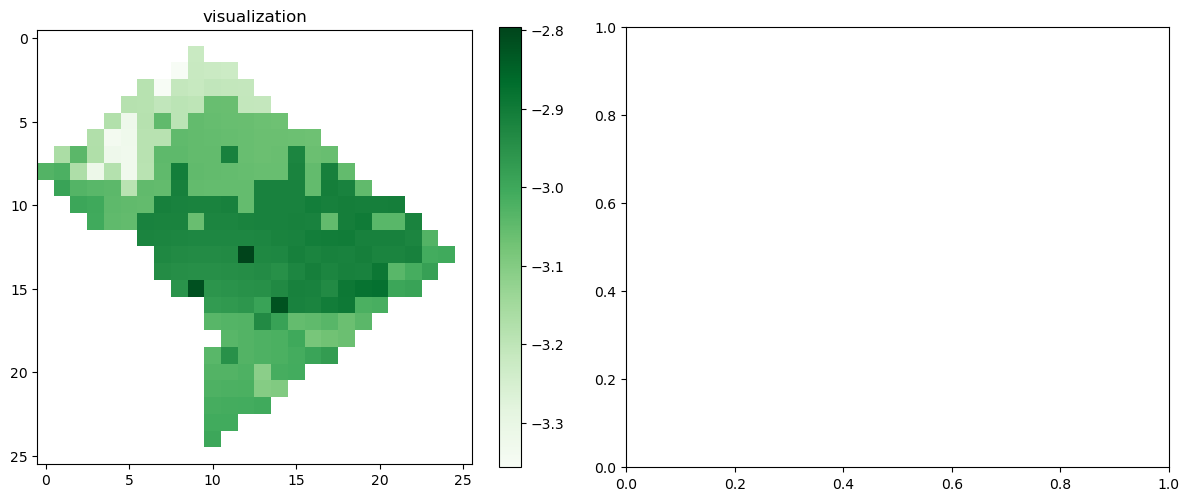

In [13]:
import geopandas as gpd
import pandas as pd
import rasterio as rio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import numpy as np
import geowombat as gw
import webbrowser
import os

# load DC bounds
dc_bounds = gpd.read_file('../data/DC_Boundary_shapefile/DC_Boundary.shp')
dc_bounds.to_crs('EPSG:4269', inplace=True)

# load census tracts
census_bounds = gpd.read_file('../data/tigerline_shapefiles/tigerline_2015_tract/tl_2015_11_tract.shp')
census_bounds.to_crs('EPSG:4269', inplace=True)

with rio.open('../data/tdmean/2015/prism_tdmean_us_30s_201503/prism_tdmean_us_30s_201503.tif') as src:
    print(src.crs)
    prism_data = src.read(1)

    # https://gis.stackexchange.com/questions/444062/clipping-raster-geotiff-with-a-vector-shapefile-in-python

    out_image, out_transform = mask(src, dc_bounds.geometry, crop=True)
    out_meta = src.meta.copy()
    
out_meta.update({
    "driver":"Gtiff",
    "height":out_image.shape[1],
    "width":out_image.shape[2],
    "transform":out_transform
})
              
with rio.open('../data/tdmean/2015/clipped_2015_tdmean.tif', 'w', **out_meta) as dst:
    dst.write(out_image)

with rio.open('../data/tdmean/2015/clipped_2015_tdmean.tif') as src:
    prism_data = src.read(1)

    prism_data.astype(np.float32)
    prism_data[prism_data == -9999] = np.nan


with gw.open('../data/tdmean/2015/clipped_2015_tdmean.tif') as src:
    df = src.gw.extract(census_bounds,
                band_names=src.band.values.tolist())
    print(df)
    print(df.columns)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    im1 = ax1.imshow(prism_data, cmap='Greens')
    df.explore()
    ax1.set_title('visualization')
    plt.colorbar(im1, ax=ax1)

    plt.tight_layout()
    plt.show()